<a href="https://colab.research.google.com/github/Andoniadou-Lab/SOX2_PPGL/blob/main/ppgl_sox2_enrichment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Download dependencies

In [1]:
!pip install decoupler==1.9.2
!pip install scanpy
!pip install scikit-misc
!pip install igraph
!pip install scvi-tools -U

ERROR: Ignored the following versions that require a different python version: 1.0.0 Requires-Python >=3.8,<3.10; 1.1.0 Requires-Python >=3.8,<3.10; 1.9.0 Requires-Python <3.12,>=3.9; 1.9.2 Requires-Python <3.12,>=3.10
ERROR: Could not find a version that satisfies the requirement decoupler==1.9.2 (from versions: 1.2.0, 1.3.0, 1.3.1, 1.3.2, 1.3.3, 1.3.4, 1.4.0, 1.5.0, 1.6.0, 1.7.0, 1.8.0, 2.0.0, 2.0.1, 2.0.2, 2.0.3, 2.0.4, 2.0.5, 2.0.6, 2.0.7, 2.1.0, 2.1.1)
ERROR: No matching distribution found for decoupler==1.9.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.4/276.4 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.5/53.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━

In [31]:
pip install gseapy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 601.3/601.3 kB 15.5 MB/s eta 0:00:00


# Import dependencies

In [2]:
#import packages
import anndata
import scanpy as sc
import scvi
import pandas as pd
import numpy as np
import os

# Mount drive with data

In [4]:
#mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [39]:
#load all_results_chrom_sox2pos_neg.csv
all_results = pd.read_csv("/content/drive/MyDrive/ppgl datasets/all_results_chrom_sox2pos_neg.csv")
results = all_results.copy()
all_genes = results["genes"]
#save as csv
all_genes.to_csv("/content/drive/MyDrive/ppgl datasets/all_genes.csv", index=False)
#keep where logFC < 0 and adj.P.Val < 0.05
results = results[(results["logFC"]<0) & (results["adj.P.Val"]<0.05)]
#remove where it starts with RPS or RPL or MT-
results = results[~results["genes"].str.startswith("RPS")]
results = results[~results["genes"].str.startswith("RPL")]
results = results[~results["genes"].str.startswith("MT-")]
#mrpl
results = results[~results["genes"].str.startswith("MRPL")]
res_genes = results["genes"]
#save as csv
res_genes.to_csv("/content/drive/MyDrive/ppgl datasets/res_genes.csv", index=False)

In [40]:
#add rank
all_results["sign"] = np.where(all_results["logFC"]>0, 1, -1)
all_results["signed_log10pval"] = np.log10(all_results["adj.P.Val"])*all_results["sign"]
all_results = all_results.sort_values(by=["signed_log10pval"], ascending=False)
all_results

,Unnamed: 0,logFC,AveExpr,t,P.Value,adj.P.Val,B,genes,comparison,sign,signed_log10pval
0,assignmentsChromaffin_cells.Chrom_SOX2_statusL...,-2.468145,4.552177,-12.243742,1.817648e-19,2.915144e-15,33.779480,PIGT,assignmentsChromaffin_cells.Chrom_SOX2_statusLow,-1,14.535340
1,assignmentsChromaffin_cells.Chrom_SOX2_statusL...,-3.043957,3.510759,-10.540914,2.186995e-16,1.198349e-12,26.840693,IMP3,assignmentsChromaffin_cells.Chrom_SOX2_statusLow,-1,11.921417
3,assignmentsChromaffin_cells.Chrom_SOX2_statusL...,-5.735499,1.802057,-10.506832,2.548878e-16,1.198349e-12,26.349916,LINC00923,assignmentsChromaffin_cells.Chrom_SOX2_statusLow,-1,11.921417
4,assignmentsChromaffin_cells.Chrom_SOX2_statusL...,-4.753630,4.160122,-10.164526,1.119980e-15,3.341646e-12,25.307767,LGALS3BP,assignmentsChromaffin_cells.Chrom_SOX2_statusLow,-1,11.476040
5,assignmentsChromaffin_cells.Chrom_SOX2_statusL...,-3.780445,1.261259,-10.132374,1.250148e-15,3.341646e-12,25.038088,SPR,assignmentsChromaffin_cells.Chrom_SOX2_statusLow,-1,11.476040
...,...,...,...,...,...,...,...,...,...,...,...
172,assignmentsChromaffin_cells.Chrom_SOX2_statusL...,1.490162,6.739829,7.610880,7.032367e-11,6.575265e-09,14.527157,CEP192,assignmentsChromaffin_cells.Chrom_SOX2_statusLow,1,-8.182087
154,assignmentsChromaffin_cells.Chrom_SOX2_statusL...,1.158939,7.791628,7.698659,4.804214e-11,5.086551e-09,14.875060,BRWD1,assignmentsChromaffin_cells.Chrom_SOX2_statusLow,1,-8.293577
119,assignmentsChromaffin_cells.Chrom_SOX2_statusL...,1.394724,8.216338,7.900016,2.002130e-11,2.675847e-09,15.724875,CLASP1,assignmentsChromaffin_cells.Chrom_SOX2_statusLow,1,-8.572539
33,assignmentsChromaffin_cells.Chrom_SOX2_statusL...,1.297646,7.995962,8.812074,3.769017e-13,1.777868e-10,19.622874,DYM,assignmentsChromaffin_cells.Chrom_SOX2_statusLow,1,-9.750101


# Plot markers

In [17]:
pdata_ppgl = sc.read_h5ad("/content/drive/MyDrive/ppgl datasets/ppgl_pbulk_chrom_sox2pos_neg.h5ad")

In [18]:
#load all_results_sig_sox2pos_neg
sig_sox2pos_neg = pd.read_csv("/content/drive/MyDrive/ppgl datasets/all_results_sig_chrom_sox2pos_neg.csv")
#keep where comparison starts with assignmentsChromaffin
sig_sox2pos_neg = sig_sox2pos_neg[sig_sox2pos_neg["comparison"].str.startswith("assignmentsChromaffin")]
#keep only where logFC	< 0
sig_sox2pos_neg = sig_sox2pos_neg[sig_sox2pos_neg["logFC"] < 0]
#take top 50 genes
results = sig_sox2pos_neg.copy()

In [19]:
#find all rows where genes starts with Wnt
wnt_table = results[results["genes"].str.startswith("WNT")]
wnt_table

,Unnamed: 0,logFC,AveExpr,t,P.Value,adj.P.Val,B,genes,comparison
45,assignmentsChromaffin_cells.Chrom_SOX2_statusL...,-4.813219,0.446155,-8.716725,5.708459e-13,2.232982e-10,18.959324,WNT3,assignmentsChromaffin_cells.Chrom_SOX2_statusLow
210,assignmentsChromaffin_cells.Chrom_SOX2_statusL...,-5.445423,0.229517,-7.511737,1.092086e-10,8.628015e-09,14.018613,WNT10A,assignmentsChromaffin_cells.Chrom_SOX2_statusLow
740,assignmentsChromaffin_cells.Chrom_SOX2_statusL...,-3.871486,0.041270,-6.318569,1.779763e-08,3.927848e-07,9.089140,WNT11,assignmentsChromaffin_cells.Chrom_SOX2_statusLow
1236,assignmentsChromaffin_cells.Chrom_SOX2_statusL...,-3.278760,0.500130,-5.548220,4.272587e-07,5.421183e-06,6.228291,WNT6,assignmentsChromaffin_cells.Chrom_SOX2_statusLow
3056,assignmentsChromaffin_cells.Chrom_SOX2_statusL...,-2.495977,-0.600061,-3.957223,1.723786e-04,8.585739e-04,0.720541,WNT9B,assignmentsChromaffin_cells.Chrom_SOX2_statusLow
5460,assignmentsChromaffin_cells.Chrom_SOX2_statusL...,-1.590568,0.074555,-2.700838,8.569073e-03,2.348040e-02,-2.755737,WNT4,assignmentsChromaffin_cells.Chrom_SOX2_statusLow
5637,assignmentsChromaffin_cells.Chrom_SOX2_statusL...,-2.203949,0.352070,-2.628461,1.042638e-02,2.755286e-02,-2.907290,WNT9A,assignmentsChromaffin_cells.Chrom_SOX2_statusLow


In [20]:
sc.pp.normalize_total(pdata_ppgl,target_sum=1e6)
sc.pp.log1p(pdata_ppgl)

In [24]:
pdata_ppgl_chrom = pdata_ppgl[pdata_ppgl.obs["broad_cluster"]=="Chromaffin_cells"]

In [69]:
genes = ["TUBB3","PAX6","RBFOX3","MAP2","NCAM1","SYT1","SNAP25","RBFOX1","RBFOX2"]

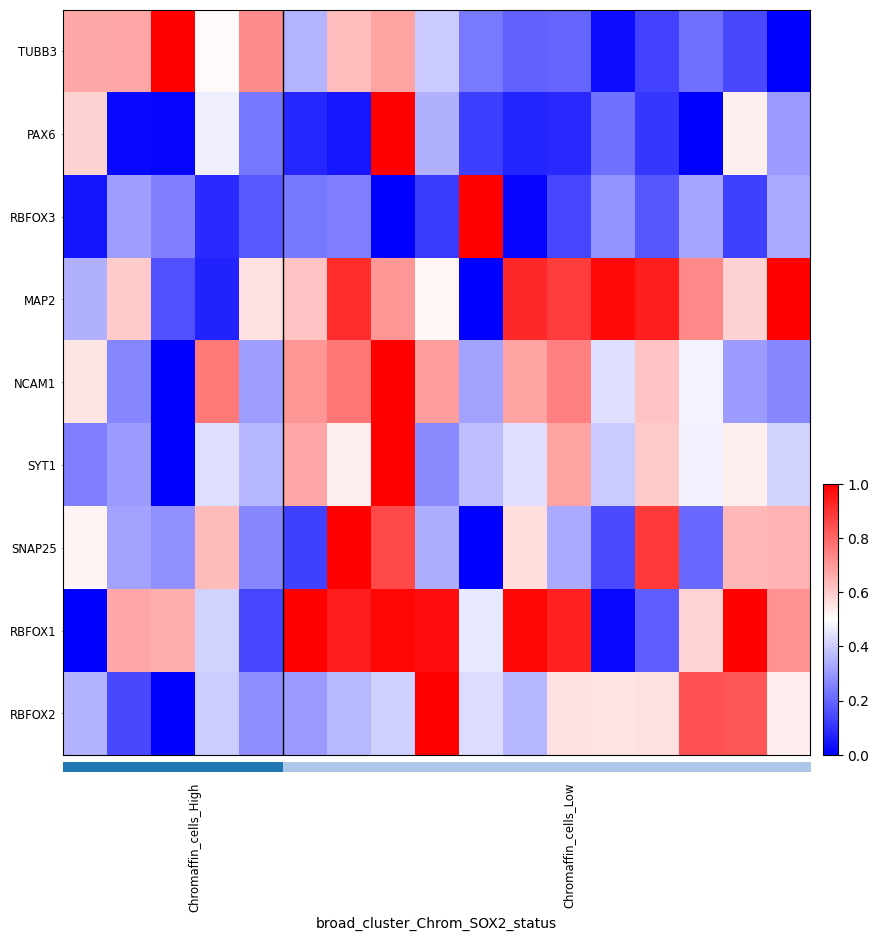

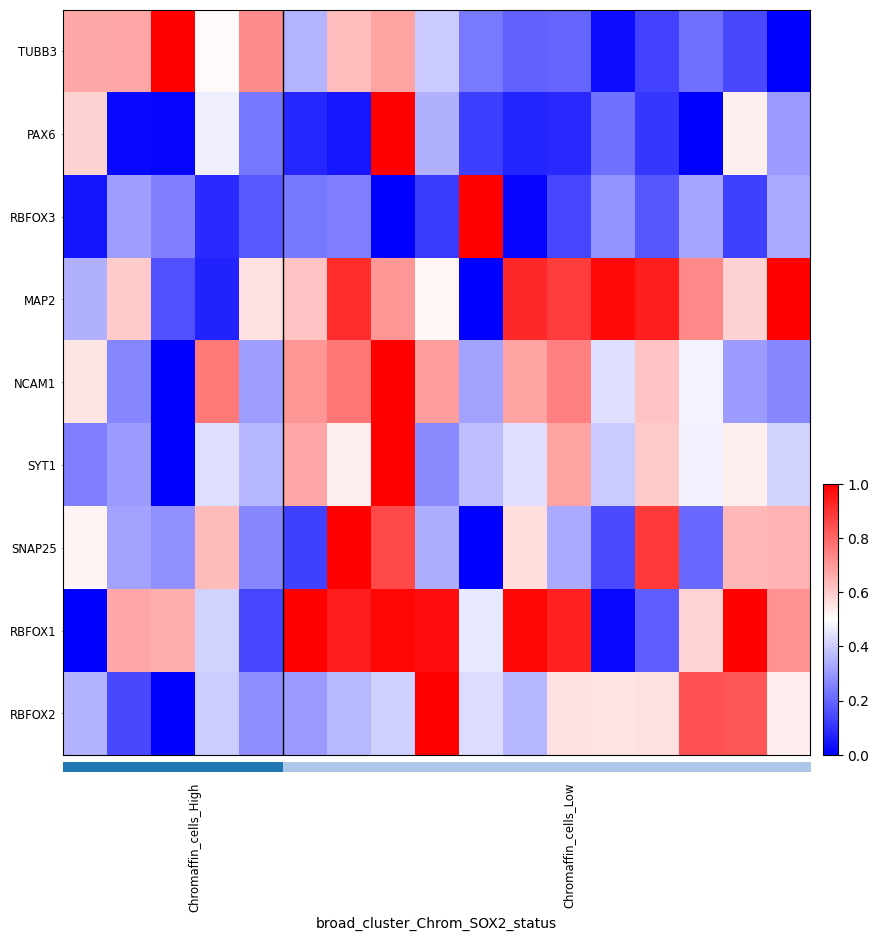

In [70]:
sc.pl.heatmap(pdata_ppgl_chrom,var_names = genes, groupby=["broad_cluster", "Chrom_SOX2_status"],log=False,standard_scale="var",swap_axes=True, cmap="bwr",figsize = (10,10),
              save = "neuronal_genes.png")

sc.pl.heatmap(pdata_ppgl_chrom,var_names = genes, groupby=["broad_cluster", "Chrom_SOX2_status"],log=False,standard_scale="var",swap_axes=True, cmap="bwr",figsize = (10,10),
              save = "neuronal_genes.svg")

# Enrichment

In [32]:
import gseapy as gp

In [33]:
from gseapy import Msigdb

In [42]:
import os

def load_gmt(file_path):
    gene_sets = {}
    with open(file_path, 'r') as file:
        for line in file:
            parts = line.strip().split('\t')
            if len(parts) >= 3:
                gene_set_name = parts[0]
                genes = parts[2:]
                gene_sets[gene_set_name] = genes
    return gene_sets

gmt_file_path = '/content/drive/MyDrive/ppgl datasets/neuronal_gene_sets.gmt'

gmt = load_gmt(gmt_file_path)
gmt

{'Neuron Cell-Cell Adhesion (GO:0007158)': ['NRXN2',
  'NLGN1',
  'ASTN2',
  'CNTN4',
  'NINJ2',
  'RET',
  'NLGN3',
  'NLGN2',
  'CDK5R1',
  'NRXN3',
  'NCAM2',
  'NRXN1',
  'NLGN4X',
  'NLGN4Y'],
 'Neuron Development (GO:0048666)': ['VPS13B',
  'NPY',
  'TOR1A',
  'STMN3',
  'ARL3',
  'EHD1',
  'ULK1',
  'HS6ST1',
  'TBC1D24',
  'BTG2',
  'GLI2',
  'PBX1',
  'TGFB2',
  'MYOC',
  'UHMK1',
  'PTPRT',
  'CAMSAP1',
  'PBX3',
  'CDNF',
  'PRDM12',
  'FLRT3',
  'INSM1',
  'VSX1',
  'B4GALT5',
  'NLGN1',
  'STMN2',
  'RAPGEF2',
  'NTRK1',
  'RAB13',
  'SNAPIN',
  'SH3GL2',
  'LYN',
  'DOCK7',
  'PTPRU',
  'POU3F2',
  'GBA2',
  'UGCG',
  'PPT1',
  'NCDN',
  'STMN1',
  'RUNX3',
  'EPHA8',
  'GRXCR1',
  'FRYL',
  'EPHA5',
  'SRRM4',
  'FRY',
  'CDK5',
  'IL6',
  'UGDH',
  'PHOX2B',
  'RAB35',
  'MICALL2',
  'HMGB1',
  'CNTNAP2',
  'CNTN4',
  'PPP1R9A',
  'PTPRZ1',
  'GPRIN3',
  'WNK1',
  'NOVA2',
  'LGI4',
  'BLOC1S3',
  'APOE',
  'PRMT1',
  'GPM6A',
  'PBX4',
  'RYK',
  'RASGRF1',
  'TMEM108'

In [34]:
msig = Msigdb()
# mouse hallmark gene sets
gmt = msig.get_gmt(category='mh.all', dbver="2023.1.Mm")

In [71]:
enr2 = gp.enrich(gene_list=all_results[(all_results["logFC"]<0) & (all_results["adj.P.Val"]<0.05)]["genes"],
                 gene_sets=['/content/drive/MyDrive/ppgl datasets/neuronal_gene_sets.gmt' ], # kegg is a dict object
                 background=all_results["genes"],
                 outdir=None,
                 verbose=True)

2025-09-23 13:47:08,868 [INFO] User defined gene sets is given: /content/drive/MyDrive/ppgl datasets/neuronal_gene_sets.gmt
2025-09-23 13:47:08,875 [INFO] Run: neuronal_gene_sets.gmt 
2025-09-23 13:47:08,888 [INFO] Done.


In [72]:
enr2.results


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
0,neuronal_gene_sets.gmt,Negative Regulation of Neuron Differentiation ...,10/18,0.005635,0.073254,3.684693,19.082171,HEY1;DLL1;SOX9;DLX2;CALR;B2M;NEPRO;MBD4;DLX1;SOX2
1,neuronal_gene_sets.gmt,Neuron Brain Human,37/144,0.470836,0.999907,1.038916,0.782558,ARF3;THY1;YWHAH;PNMA2;TH;ISOC1;DLX2;SYT11;TRHD...
2,neuronal_gene_sets.gmt,Neuron Cell-Cell Adhesion (GO:0007158),1/14,0.982676,0.999907,0.330550,0.005777,RET
3,neuronal_gene_sets.gmt,Neuron Development (GO:0048666),30/142,0.887400,0.999907,0.805679,0.096246,ARL3;XBP1;STMN4;RAB13;BLOC1S4;BLOC1S1;ATP7A;CL...
4,neuronal_gene_sets.gmt,Neuron Differentiation (GO:0030182),29/130,0.800762,0.999907,0.864299,0.192040,RTN4;XBP1;ID3;NGRN;DDIT4;WNT9B;WNT3;SOX2;WNT9A...
5,neuronal_gene_sets.gmt,Neuron Fate Commitment (GO:0048663),1/9,0.926226,0.999907,0.525210,0.040251,DLL1
6,neuronal_gene_sets.gmt,Neuron Fate Specification (GO:0048665),1/6,0.824065,0.999907,0.811890,0.157106,DLL1
7,neuronal_gene_sets.gmt,Neuron Maturation (GO:0042551),2/16,0.938099,0.999907,0.513006,0.032781,MTCH1;CLN5
8,neuronal_gene_sets.gmt,Neuron Migration (GO:0001764),5/57,0.999577,0.999907,0.310956,0.000131,DNAAF3;TUBB2B;DDIT4;TUBB2A;CDK5
9,neuronal_gene_sets.gmt,Neuron Projection (GO:0043005),86/474,0.999907,0.999907,0.655485,0.000061,TH;RGS14;MUL1;PRLHR;GSK3A;SSTR2;SLC12A5;RBM3;W...


In [73]:
all_results[["genes","signed_log10pval"]].head(20)

,genes,signed_log10pval
0,PIGT,14.535340
1,IMP3,11.921417
3,LINC00923,11.921417
4,LGALS3BP,11.476040
5,SPR,11.476040
6,STMN1,11.409099
7,SOX2,11.145985
10,CFAP58-DT,10.943872
9,HINT2,10.772075
8,TM9SF1,10.772075


In [74]:
pre_res = gp.prerank(rnk=all_results[["genes","signed_log10pval"]],
                     gene_sets=gmt,
                     gene_sets_pval_cutoff=0.05,
                     threads=4,
                     min_size=5,
                     max_size=1000,
                     permutation_num=1000, # reduce number to speed up testing
                     outdir=None, # don't write to disk
                     seed=6,
                     verbose=True, # see what's going on behind the scenes
                    )

2025-09-23 13:47:21,509 [WARNING] Duplicated values found in preranked stats: 12.78% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-09-23 13:47:21,509 [INFO] Parsing data files for GSEA.............................
2025-09-23 13:47:21,533 [INFO] 0000 gene_sets have been filtered out when max_size=1000 and min_size=5
2025-09-23 13:47:21,534 [INFO] 0013 gene_sets used for further statistical testing.....
2025-09-23 13:47:21,535 [INFO] Start to run GSEA...Might take a while..................
2025-09-23 13:47:22,866 [INFO] Congratulations. GSEApy runs successfully................



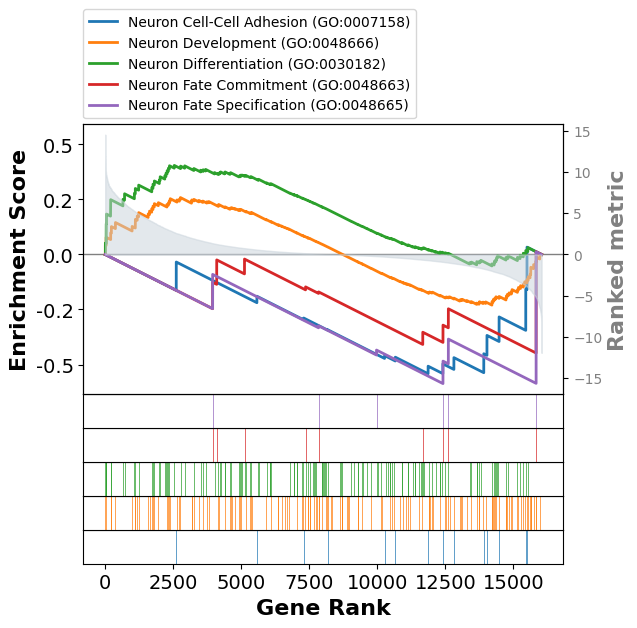

In [78]:
axs = pre_res.plot(terms=list(gmt.keys())[:5],
                   #legend_kws={'loc': (1.2, 0)}, # set the legend loc
                   show_ranking=True, # whether to show the second yaxis
                   figsize=(3,4),
                  )

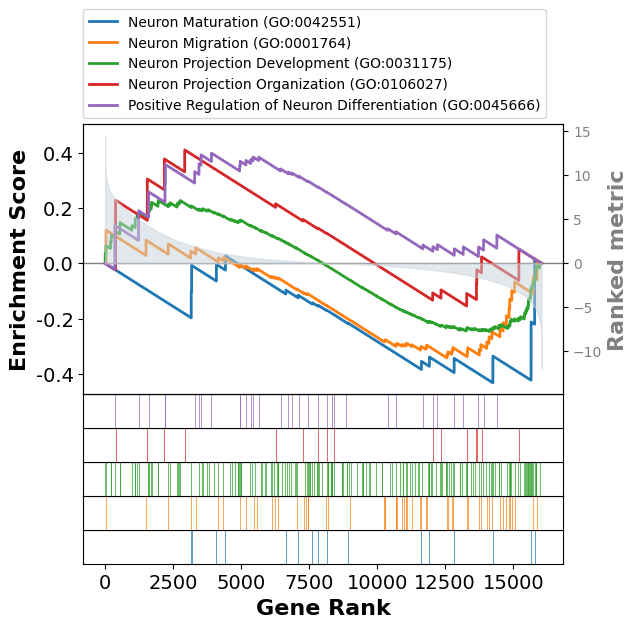

In [79]:
axs = pre_res.plot(terms=list(gmt.keys())[5:10],
                   #legend_kws={'loc': (1.2, 0)}, # set the legend loc
                   show_ranking=True, # whether to show the second yaxis
                   figsize=(3,4),
                  )

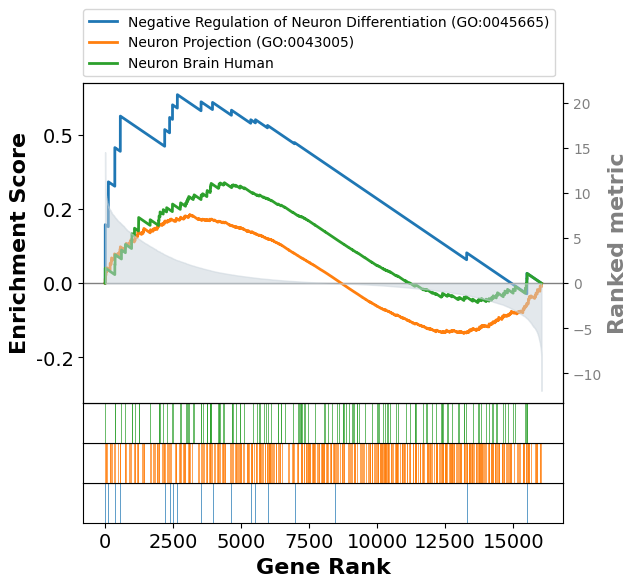

In [80]:
axs = pre_res.plot(terms=list(gmt.keys())[10:],
                   #legend_kws={'loc': (1.2, 0)}, # set the legend loc
                   show_ranking=True, # whether to show the second yaxis
                   figsize=(3,4),
                  )